In [1]:
import sys
sys.path.append("../../")  # Para que encuentre src/ desde la carpeta notebooks
import numpy as np
from src.data.ingestion import descargar_ticker, cargar_raw
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = descargar_ticker("AAPL", inicio="2020-01-01", fin="2024-01-01")
print(df.columns)
df.head()

2026-02-26 03:55:05.199 | INFO     | src.data.ingestion:descargar_ticker:15 - Descargando AAPL desde 2020-01-01 hasta 2024-01-01...
[*********************100%***********************]  1 of 1 completed
2026-02-26 03:55:05.849 | INFO     | src.data.ingestion:descargar_ticker:27 - Descargados 1006 registros para AAPL.
2026-02-26 03:55:05.863 | INFO     | src.data.ingestion:guardar_raw:52 - Datos guardados en D:\PROYECTOS\DETECTOR_ANOM\data\raw\AAPL.csv


Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')


Price,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,71.409785,72.460784,71.156682,72.400520,135480400
2020-01-03,71.629130,72.455943,71.472447,71.696625,146322800
2020-01-06,70.819208,72.306506,70.568510,72.267937,118387200
2020-01-07,72.277563,72.533080,71.708680,71.928040,108872000
2020-01-08,71.631567,73.386438,71.631567,73.085121,132079200


In [3]:
print(df.columns)
print(df.dtypes)

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
Price
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


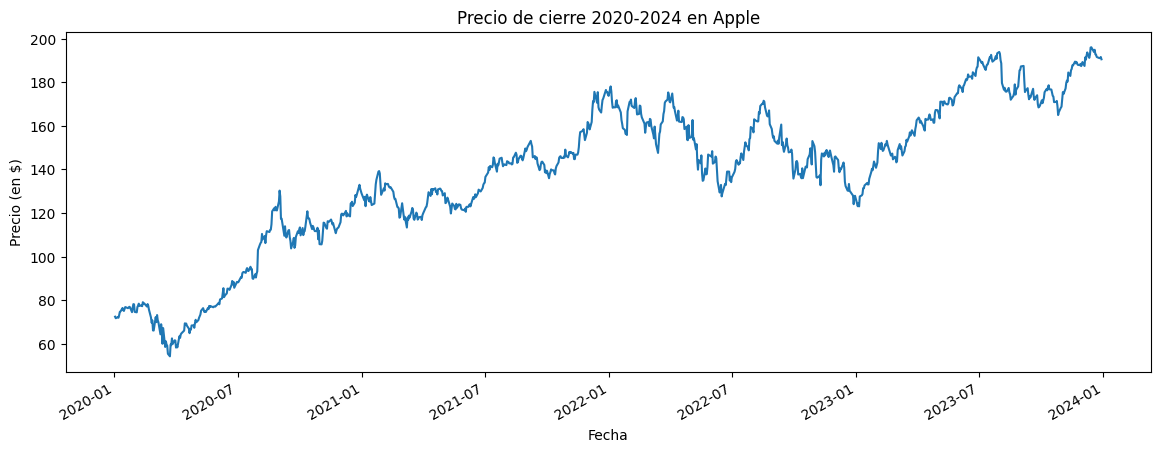

In [4]:
# Visualización del precio de cierre
df["Close"].plot(figsize=(14,5), title="Precio de cierre 2020-2024 en Apple")
plt.xlabel("Fecha")
plt.ylabel("Precio (en $)")
plt.show()

In [5]:
# Comprobaciones para preprocesamiento
print(df.isnull().sum)

<bound method DataFrame.sum of Price        Open   High    Low  Close  Volume
Date                                          
2020-01-02  False  False  False  False   False
2020-01-03  False  False  False  False   False
2020-01-06  False  False  False  False   False
2020-01-07  False  False  False  False   False
2020-01-08  False  False  False  False   False
...           ...    ...    ...    ...     ...
2023-12-22  False  False  False  False   False
2023-12-26  False  False  False  False   False
2023-12-27  False  False  False  False   False
2023-12-28  False  False  False  False   False
2023-12-29  False  False  False  False   False

[1006 rows x 5 columns]>


In [6]:
df.describe()

Price,Open,High,Low,Close,Volume
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.827953,139.439050,136.328683,137.957993,9.895373e+07
std,33.351565,33.477922,33.218686,33.357829,5.439610e+07
min,55.110034,55.211516,51.372081,54.213600,2.404830e+07
25%,120.502568,121.638025,118.864113,120.397030,6.407675e+07
50%,142.666132,144.390239,141.154845,142.816368,8.467540e+07
75%,163.462858,165.471091,161.941430,163.195053,1.155069e+08
max,195.984034,197.567574,194.974519,196.073105,4.265100e+08


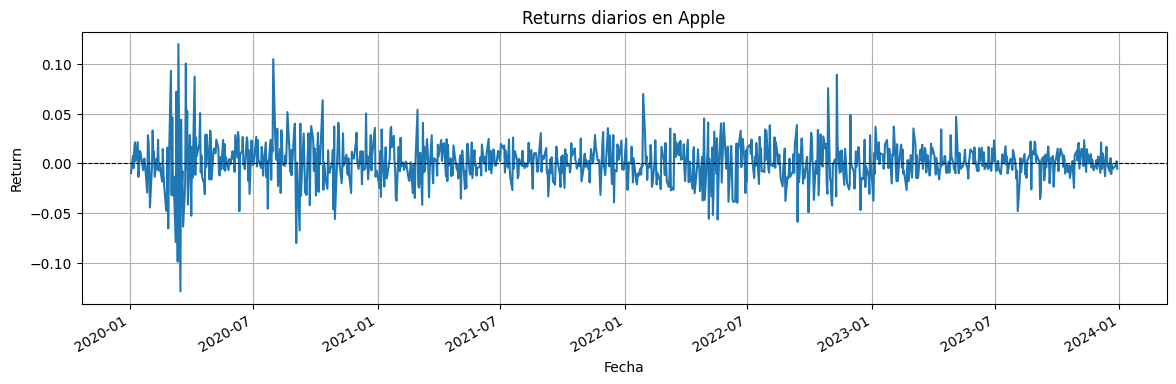

count    1005.000000
mean        0.001187
std         0.021146
min        -0.128647
25%        -0.009128
50%         0.000988
75%         0.012743
max         0.119808
Name: Return, dtype: float64


In [7]:
df["Return"] = df["Close"].pct_change()

df["Return"].plot(figsize=(14,4), title="Returns diarios en Apple")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Fecha")
plt.ylabel("Return")
plt.grid(True)
plt.show()

print(df["Return"].describe())

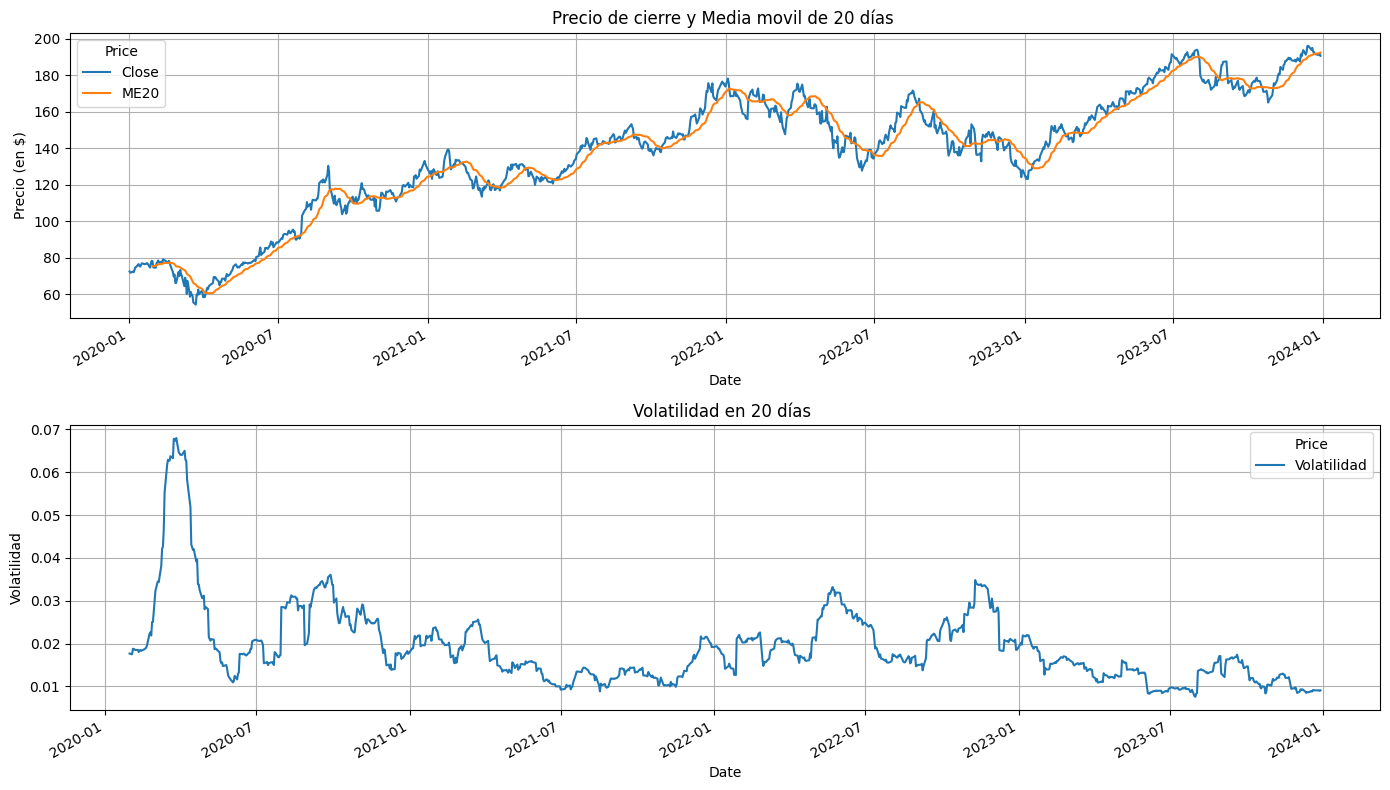

In [8]:
# Media movil de 20 días
df["ME20"] = df["Close"].rolling(window=20).mean()

# Volatilidad: desv en 20 dias
df["Volatilidad"] = df["Return"].rolling(window=20).std()

fig, axes = plt.subplots(2,1, figsize=(14,8))
df[ ["Close", "ME20"] ].plot(ax=axes[0], title="Precio de cierre y Media movil de 20 días ")
axes[0].set_ylabel("Precio (en $)")
axes[0].grid(True)

df[ ["Volatilidad"] ].plot(ax=axes[1], title="Volatilidad en 20 días ")
axes[1].set_ylabel("Volatilidad")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Observamos el df con las nuevas columnas
df_caract = df[ ["Close", "Return", "ME20", "Volatilidad"] ].dropna()

print(f"Filas originales: {len(df)}")
print(f"Filas tras dropna: {len(df_caract)}")
print(f"\nPrimeras filas:")
df_caract.head()

Filas originales: 1006
Filas tras dropna: 986

Primeras filas:


Price,Close,Return,ME20,Volatilidad
Date,,,,
2020-01-31,74.608566,-0.044339,75.327992,0.017679
2020-02-03,74.403671,-0.002746,75.463345,0.017511
2020-02-04,76.860016,0.033014,75.692949,0.018808
2020-02-05,77.486771,0.008154,75.970885,0.018741
2020-02-06,78.393120,0.011697,76.236285,0.018616


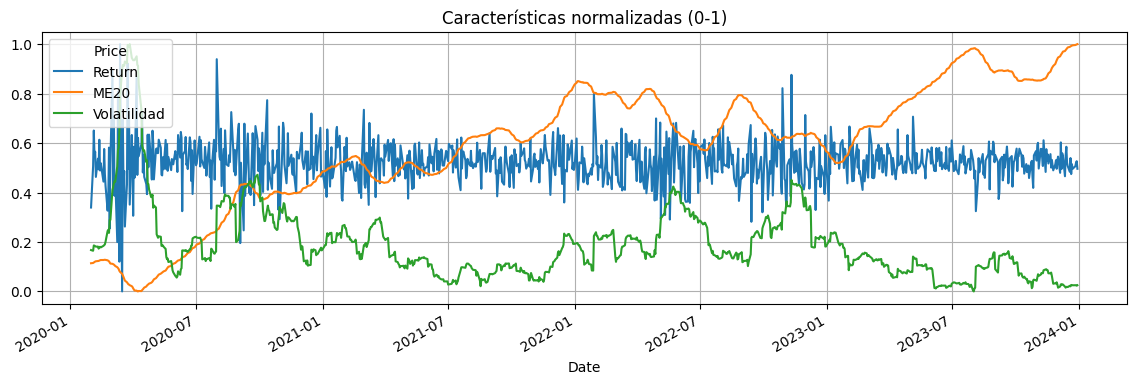

Price,Return,ME20,Volatilidad
count,986.000000,986.000000,986.000000
mean,0.522339,0.589495,0.192825
std,0.085555,0.244560,0.156101
min,0.000000,0.000000,0.000000
25%,0.480793,0.459602,0.095404
50%,0.520912,0.625572,0.153779
75%,0.569031,0.781408,0.240270
max,1.000000,1.000000,1.000000


In [10]:
# Normalización
caract = ["Return", "ME20", "Volatilidad"]
scaler = MinMaxScaler()

df_scaled = df_caract.copy()
df_scaled[caract] = scaler.fit_transform(df_caract[caract])

df_scaled[caract].plot(figsize=(14,4), title="Características normalizadas (0-1)")
plt.grid(True)
plt.show()

df_scaled[caract].describe()


In [11]:
SEQ = 30
def construir_secuencias(datos: np.ndarray, seq: int) -> np.ndarray:
    secuencias = []
    for i in range(len(datos) - seq):
        secuencias.append(datos[i : i + seq])
    return np.array(secuencias)

X = construir_secuencias(df_scaled[caract].values, SEQ)
# Agrupamos en secuencias de días, ya que es como LSTM procesa los datos
print(f"Shape de X: {X.shape}")
print(f"Interpretación: {X.shape[0]} secuencias de {X.shape[1]} días con {X.shape[2]} features")

Shape de X: (956, 30, 3)
Interpretación: 956 secuencias de 30 días con 3 features


In [12]:
from src.data.preprocessing import pipeline
from src.data.ingestion import cargar_raw

df_crudo = cargar_raw("AAPL")
X, scaler = pipeline(df_crudo)

print(f"Shape final: {X.shape}")
print(f"Mínimo: {X.min():.4f} | Máximo: {X.max():.4f}")

2026-02-26 03:55:07.269 | INFO     | src.data.preprocessing:pipeline:78 - Iniciando pipeline de preprocesamiento...
2026-02-26 03:55:07.270 | INFO     | src.data.preprocessing:calcular_caract:16 - Calculando caract con ventana=20
2026-02-26 03:55:07.278 | INFO     | src.data.preprocessing:calcular_caract:33 - Características calculadas: Filas: 1006 -> 987(eliminadas 1006 - 987 por NaN)
2026-02-26 03:55:07.279 | INFO     | src.data.preprocessing:normalizar:48 - Normalización de características
2026-02-26 03:55:07.286 | INFO     | src.data.preprocessing:construir_secuencias:67 - Secuencias construidas: 957 secuencias de 30 días × 3 features
2026-02-26 03:55:07.287 | INFO     | src.data.preprocessing:pipeline:82 - Pipeline completado. Tamaño final: (957, 30, 3)


Shape final: (957, 30, 3)
Mínimo: 0.0000 | Máximo: 1.0000
